In [1]:
from inspect import FrameInfo
from google.colab import drive
drive.mount('/content/drive')

import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.font_manager as fm

font_path = '/content/drive/MyDrive/kwukdt/data-analysis/data-pre-processing/NanumGothic.ttf'

fm.fontManager.addfont(font_path)
mpl.rc('font', family = 'NanumGothic')
plt.rcParams['axes.unicode_minus'] = False

Mounted at /content/drive


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

titanic = pd.read_csv('/content/drive/MyDrive/kwukdt/data-analysis/data-pre-processing/train.csv')
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [17]:
from sklearn.preprocessing import MinMaxScaler, StandardScaler, RobustScaler

In [18]:
titanic_clean=titanic.copy()

titanic_clean=titanic_clean.drop(columns=['Cabin'])

titanic_clean['Age']=titanic_clean.groupby(['Sex','Pclass'])['Age'].transform(
    lambda x:x.fillna(x.median())
)

titanic_clean['Embarked']=titanic_clean['Embarked'].fillna(
    titanic_clean['Embarked'].mode()[0]
)

In [19]:
features = ['Age', 'Fare', 'SibSp', 'Parch']
df = titanic_clean[features].dropna().copy()

print(df.describe().round(2))
print(df.shape)

          Age    Fare   SibSp   Parch
count  891.00  891.00  891.00  891.00
mean    29.11   32.20    0.52    0.38
std     13.30   49.69    1.10    0.81
min      0.42    0.00    0.00    0.00
25%     21.50    7.91    0.00    0.00
50%     26.00   14.45    0.00    0.00
75%     36.00   31.00    1.00    0.00
max     80.00  512.33    8.00    6.00
(891, 4)


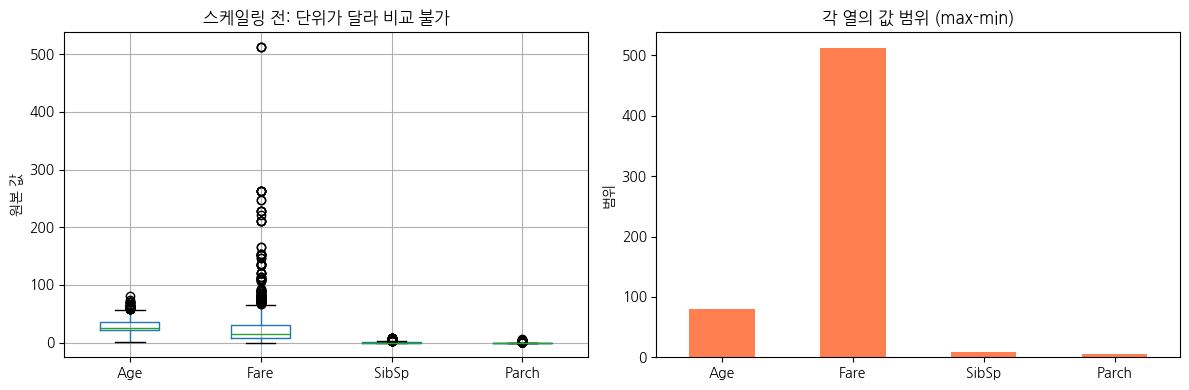

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df.boxplot(ax=axes[0])
axes[0].set_title('스케일링 전: 단위가 달라 비교 불가')
axes[0].set_ylabel('원본 값')

ranges = df.max() - df.min()
ranges.plot(kind='bar', ax=axes[1], color='coral')
axes[1].set_title('각 열의 값 범위 (max-min)')
axes[1].set_ylabel('범위')
axes[1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

In [25]:
standard_scaler = StandardScaler()
df_standard = pd.DataFrame(
    standard_scaler.fit_transform(df),
    columns=df.columns
)
print("StandardScaler 결과: ")
print(df_standard.describe().round(3))

print(standard_scaler.mean_.round(2))
print(standard_scaler.scale_.round(2))

StandardScaler 결과: 
           Age     Fare    SibSp    Parch
count  891.000  891.000  891.000  891.000
mean     0.000    0.000    0.000    0.000
std      1.001    1.001    1.001    1.001
min     -2.158   -0.648   -0.475   -0.474
25%     -0.572   -0.489   -0.475   -0.474
50%     -0.234   -0.357   -0.475   -0.474
75%      0.518   -0.024    0.433   -0.474
max      3.827    9.667    6.784    6.974
[29.11 32.2   0.52  0.38]
[13.3  49.67  1.1   0.81]


In [27]:
robust_scaler = RobustScaler()
df_robust = pd.DataFrame(
    robust_scaler.fit_transform(df),
    columns=df.columns
)

print("RobustScaler 결과: ")
print(df_robust.describe().round(3))
print(robust_scaler.center_.round(3))
print(robust_scaler.scale_.round(3))

RobustScaler 결과: 
           Age     Fare    SibSp    Parch
count  891.000  891.000  891.000  891.000
mean     0.215    0.769    0.523    0.382
std      0.918    2.152    1.103    0.806
min     -1.764   -0.626    0.000    0.000
25%     -0.310   -0.283    0.000    0.000
50%      0.000    0.000    0.000    0.000
75%      0.690    0.717    1.000    0.000
max      3.724   21.563    8.000    6.000
[26.    14.454  0.     0.   ]
[14.5  23.09  1.    1.  ]


In [28]:
minmax_scaler = MinMaxScaler()
df_minmax = pd.DataFrame(
    minmax_scaler.fit_transform(df),
    columns=df.columns
)

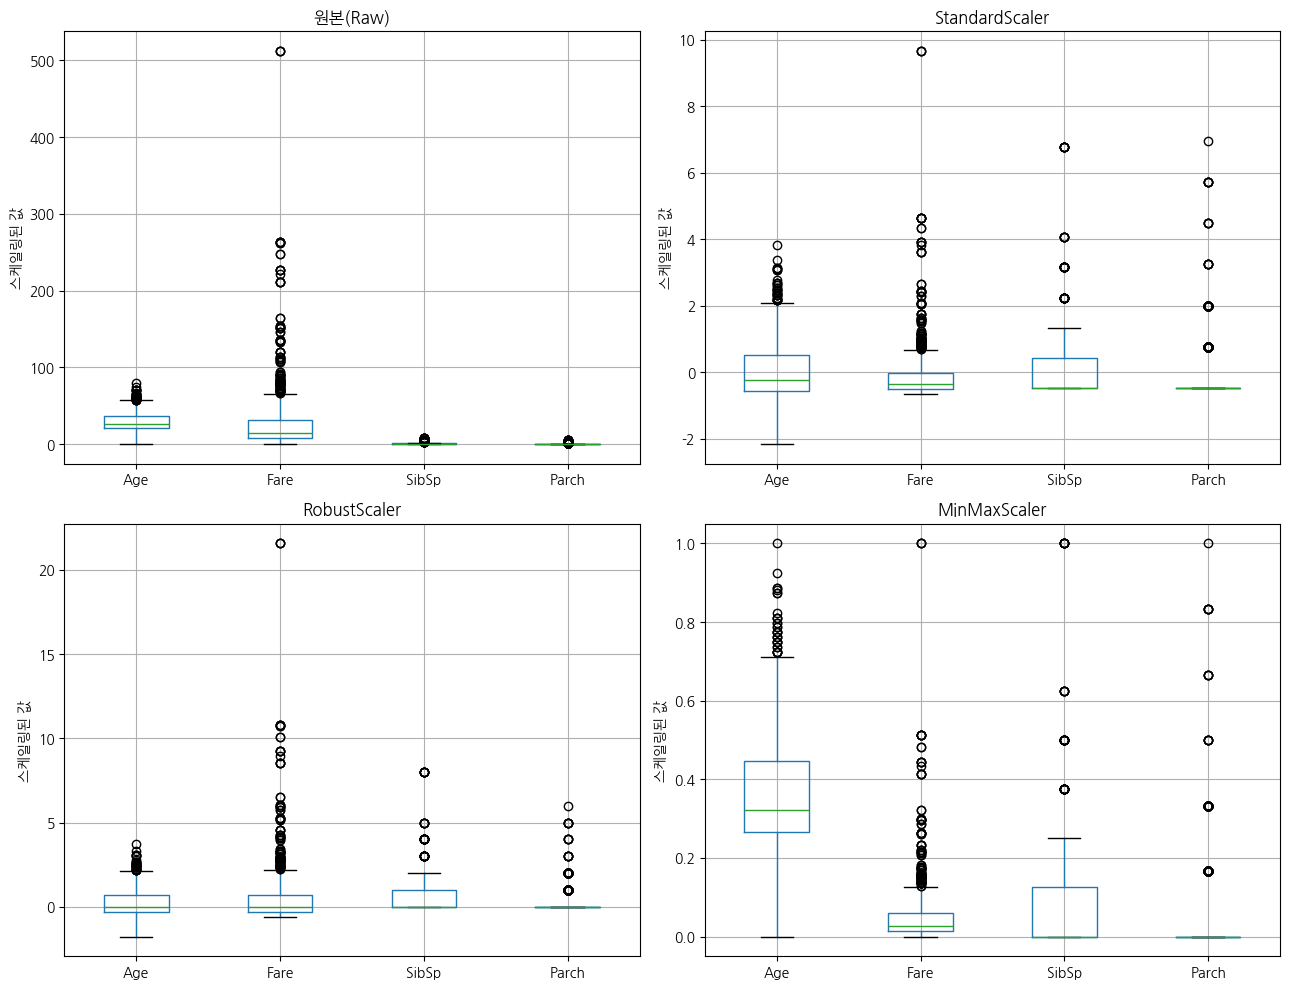

In [30]:
fig, axes = plt.subplots(2, 2, figsize=(13, 10))
datasets = {
    '원본(Raw)': df,
    'StandardScaler': df_standard,
    'RobustScaler': df_robust,
    'MinMaxScaler': df_minmax
}

for ax, (title, data) in zip(axes.flatten(), datasets.items()):
    data.boxplot(ax=ax)
    ax.set_title(title)
    ax.set_ylabel('스케일링된 값')
    ax.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

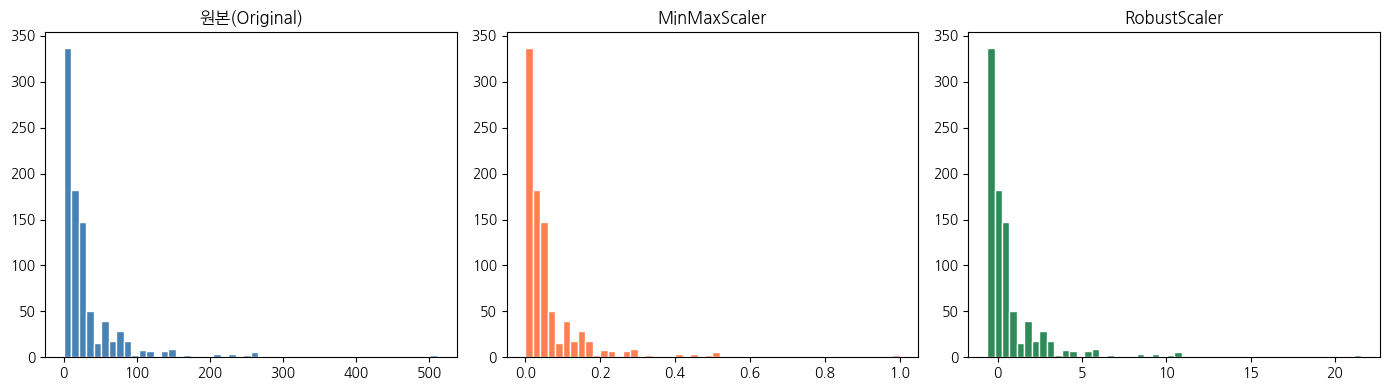

MinMaxScaler의 중앙 50%: 0.015~0.061
RobustScaler의 중앙 50%: -0.283~0.717


In [35]:
fare = df[['Fare']].copy()

mm = MinMaxScaler()
fare_mm = mm.fit_transform(fare)

rb = RobustScaler()
fare_rb = rb.fit_transform(fare)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].hist(fare['Fare'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('원본(Original)')
axes[1].hist(fare_mm, bins=50, color='coral', edgecolor='white')
axes[1].set_title('MinMaxScaler')
axes[2].hist(fare_rb, bins=50, color='seagreen', edgecolor='white')
axes[2].set_title('RobustScaler')

plt.tight_layout()
plt.show()

print(f"MinMaxScaler의 중앙 50%: {np.percentile(fare_mm, 25):.3f}~{np.percentile(fare_mm, 75):.3f}")
print(f"RobustScaler의 중앙 50%: {np.percentile(fare_rb, 25):.3f}~{np.percentile(fare_rb, 75):.3f}")

In [36]:
from sklearn.model_selection import train_test_split

X = df[['Age', 'Fare']]
X_train, X_test = train_test_split(X, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape)

(712, 2) (179, 2)


In [39]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
scaler.fit(X_train)
X_test_scaled = scaler.transform(X_test)

train_df = pd.DataFrame(X_train_scaled, columns=['Age', 'Fare'])
test_df = pd.DataFrame(X_test_scaled, columns=['Age', 'Fare'])
print(train_df.mean().round(4).values)
print(test_df.mean().round(4).values)

[-0.  0.]
[ 0.0733 -0.0366]


In [41]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

clean_data_for_scaling = titanic_clean[['Age', 'Fare', 'SibSp', 'Parch']].copy()

pipe_scaled_only = Pipeline([
    ('scaler', StandardScaler())
])
result_scaled_only = pipe_scaled_only.fit_transform(clean_data_for_scaling)